In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso, ElasticNet, Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report, roc_curve, auc, root_mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn import datasets, svm
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


Przygotowanie danych 
1.1. Wczytanie danych, sprawdzenie typów danych i kompletności danych, podstawowe statystyki.

In [55]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.isnull().sum())
print(df.describe())
print(df.dtypes)
df.head()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7032.000000  7032.000000     7032.000000   7032.000000
mean        0.162400    32.421786       64.798208   2283.300441
std         0.368844    24.545260       30.085974   2266.771362
min         0.000000     1.000000       18.250000     18.800000
25%         0.000000     9.000000       35.587500    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.862500   3794.737500
max         1

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### 1.2. Utworzenie wykresu słupkowego: 
##### 1.2.1. ilości wystąpień kategorii dotyczącej atrybutu decyzyjnego, 

C:\Users\DELL\AppData\Local\Temp\ipykernel_7304\895717906.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, palette="viridis")


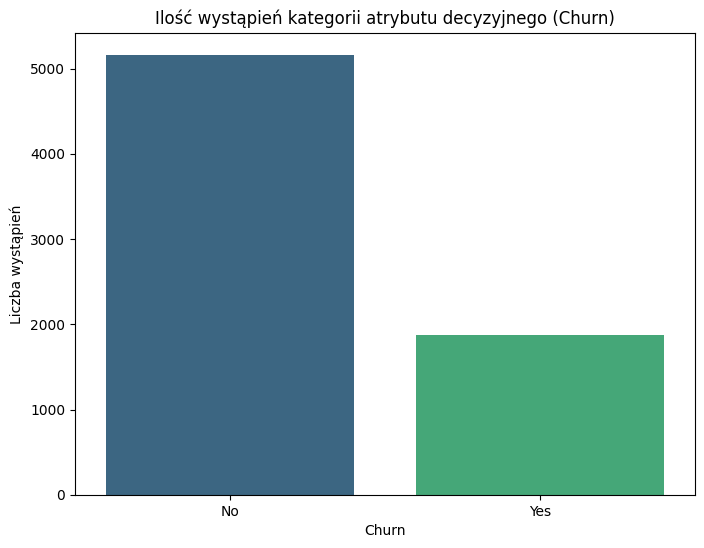

In [56]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette="viridis")
plt.title("Ilość wystąpień kategorii atrybutu decyzyjnego (Churn)")
plt.xlabel("Churn")
plt.ylabel("Liczba wystąpień")
plt.show()

##### 1.2.2. atrybut decyzyjny według płci. 

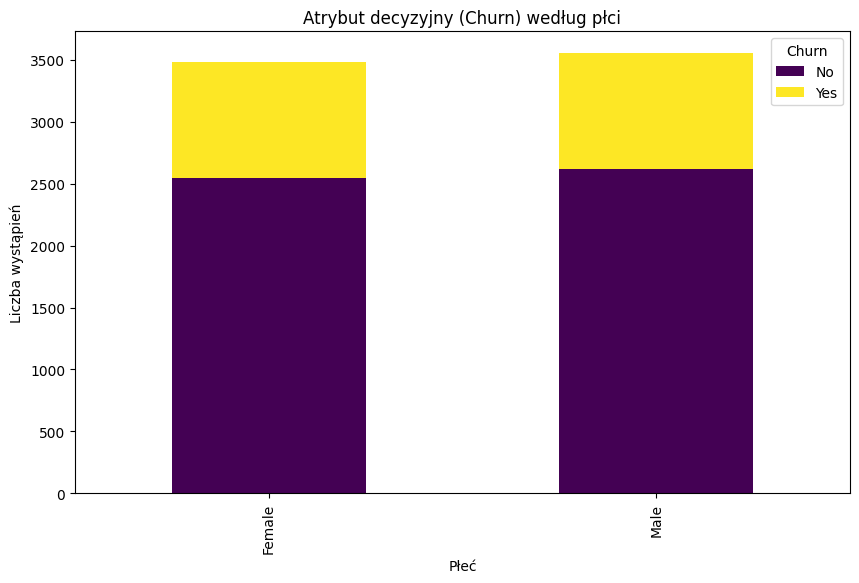

In [57]:
churn_gender = df.groupby(['gender', 'Churn']).size().unstack()

churn_gender.plot(kind='bar', stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Atrybut decyzyjny (Churn) według płci")
plt.xlabel("Płeć")
plt.ylabel("Liczba wystąpień")
plt.legend(title="Churn")
plt.show()

##### 1.3. Wykres pudełkowy: 
##### 1.3.1. opłat całkowitych w zależności od klientów, którzy odeszli w ciągu ostatniego miesiąca. 

C:\Users\DELL\AppData\Local\Temp\ipykernel_7304\1918898716.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='TotalCharges', palette="viridis")


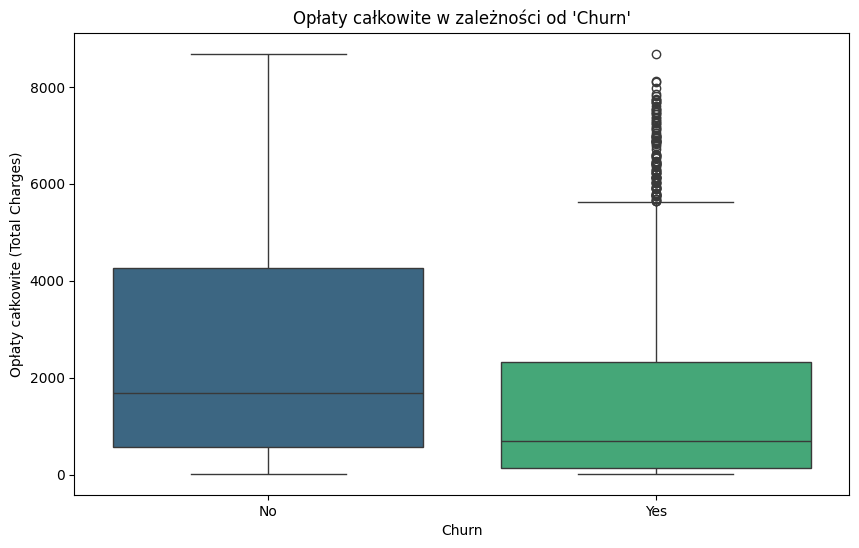

In [58]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='TotalCharges', palette="viridis")
plt.title("Opłaty całkowite w zależności od 'Churn'")
plt.xlabel("Churn")
plt.ylabel("Opłaty całkowite (Total Charges)")
plt.show()

##### 1.3.2.  ‘churn’ klientów w zależności długości czasu korzystania z usług. 

C:\Users\DELL\AppData\Local\Temp\ipykernel_7304\2897629365.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette="viridis")


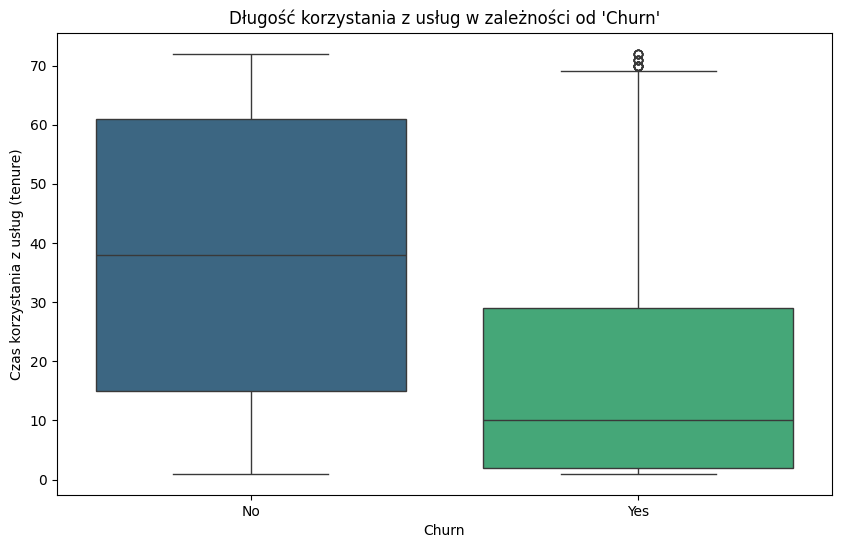

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='tenure', palette="viridis")
plt.title("Długość korzystania z usług w zależności od 'Churn'")
plt.xlabel("Churn")
plt.ylabel("Czas korzystania z usług (tenure)")
plt.show()

1.4. Wykres pudełkowy opłat całkowitych w zależności od rodzaju umowy z uwzględnieniem, klientów, 
którzy odeszli w ciągu ostatniego miesiąca 'Churn'.

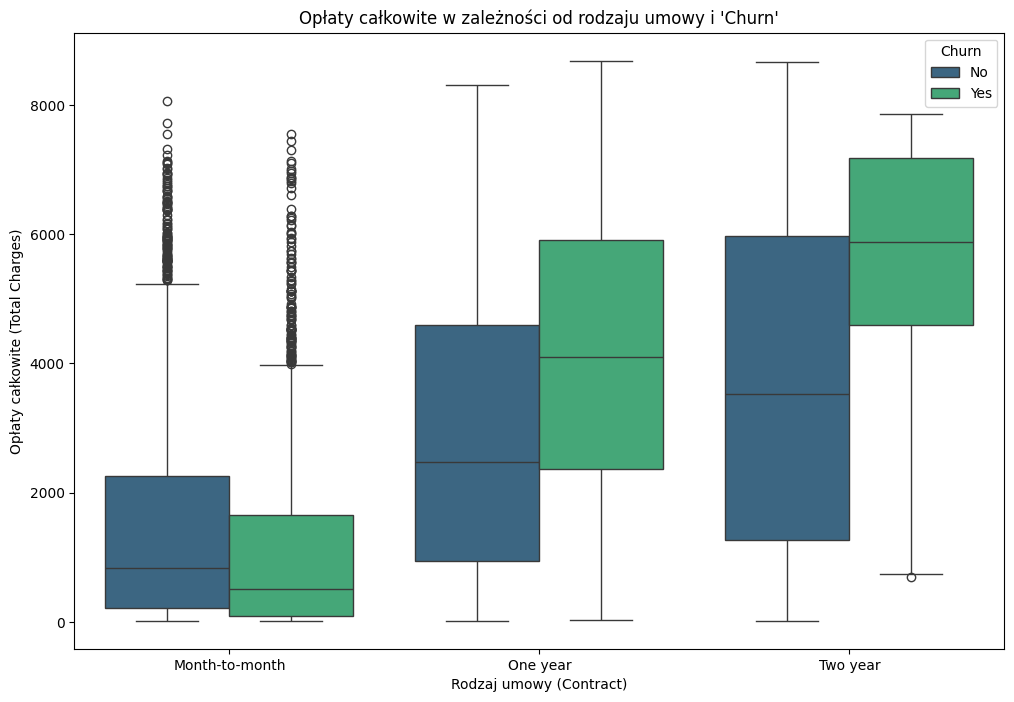

In [60]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='Contract', y='TotalCharges', hue='Churn', palette="viridis")
plt.title("Opłaty całkowite w zależności od rodzaju umowy i 'Churn'")
plt.xlabel("Rodzaj umowy (Contract)")
plt.ylabel("Opłaty całkowite (Total Charges)")
plt.legend(title="Churn")
plt.show()

1.5. Utworzenie wykresu słupkowego wielkości korelacji z wyłączeniem cech ('customerID', 'tenure', 'MonthlyCharges',  'TotalCharges')  z ‘Churn’  yes.  Niektóre  kolumny  kategorialne  należy przekonwertować na zmienne fikcyjne. 

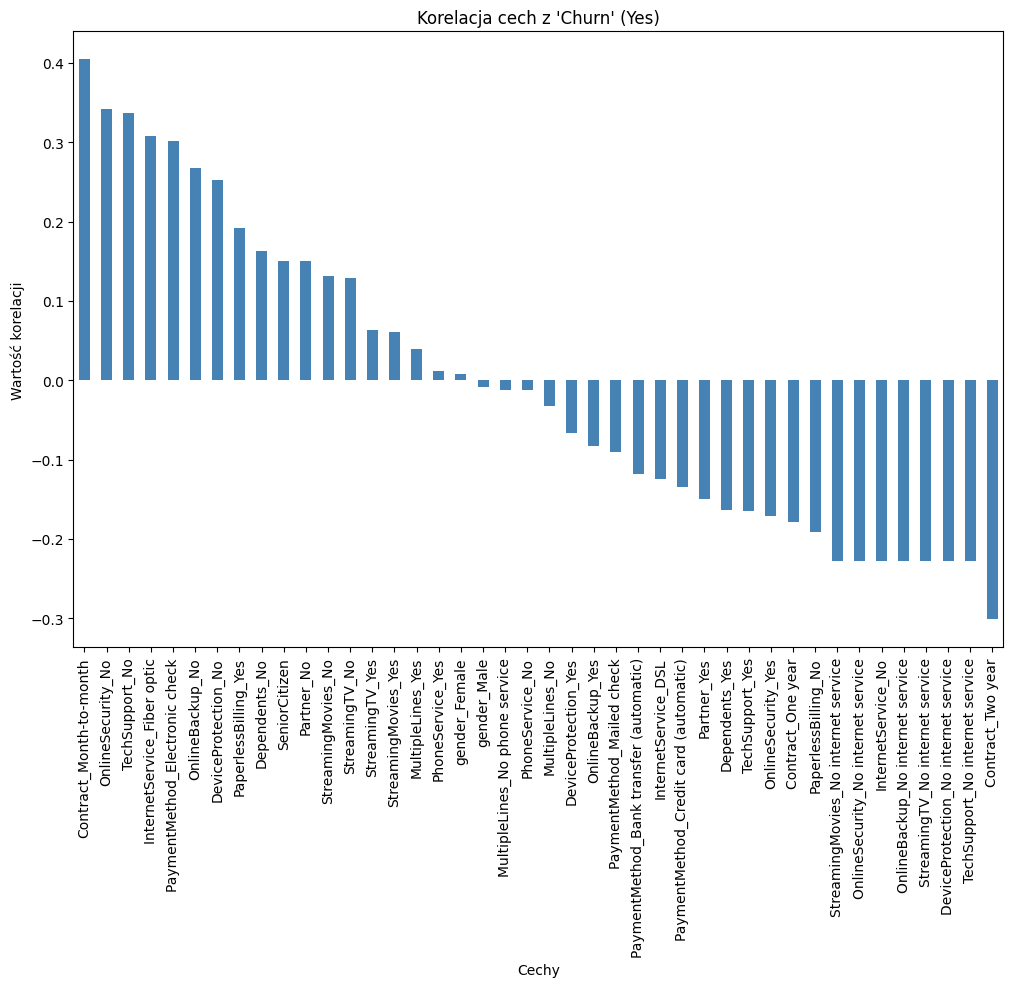

In [61]:
# Wybór zmiennych istotnych dla analizy korelacji
selected_columns = df.drop(['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges'], axis=1)
df_encoded_reduced = pd.get_dummies(selected_columns, drop_first=False)
df_encoded_reduced = df_encoded_reduced.drop(columns=['Churn_No'])

# Oblicz korelacje dla zmniejszonego zbioru danych
correlations_reduced = df_encoded_reduced.corr()['Churn_Yes'].drop('Churn_Yes')

# Wykres słupkowy korelacji
plt.figure(figsize=(12, 8))
correlations_reduced.sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title("Korelacja cech z 'Churn' (Yes)")
plt.xlabel("Cechy")
plt.ylabel("Wartość korelacji")
plt.show()

In [62]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

1.6. Jakie są rodzaje zawieranych umów? 

In [63]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

1.7. Rozkład różnych usług używanych przez klientów. 

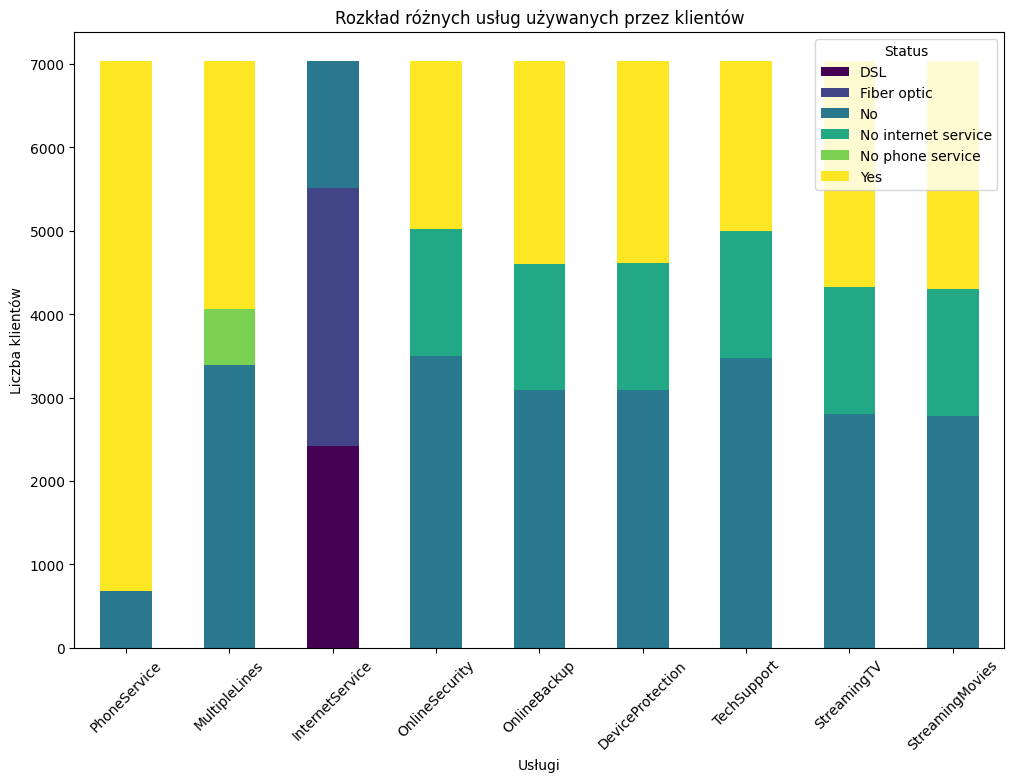

In [64]:
services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 
            'StreamingTV', 'StreamingMovies']

service_distribution = df[services].apply(lambda x: x.value_counts())

# Wykres słupkowy dla każdej usługi
service_distribution.T.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis')
plt.title("Rozkład różnych usług używanych przez klientów")
plt.xlabel("Usługi")
plt.ylabel("Liczba klientów")
plt.xticks(rotation=45)
plt.legend(title="Status")
plt.show()

1.8. Utworzenie histogramu przedstawiającego rozkład długości czasu korzystania z usług (zmienna 'tenure').

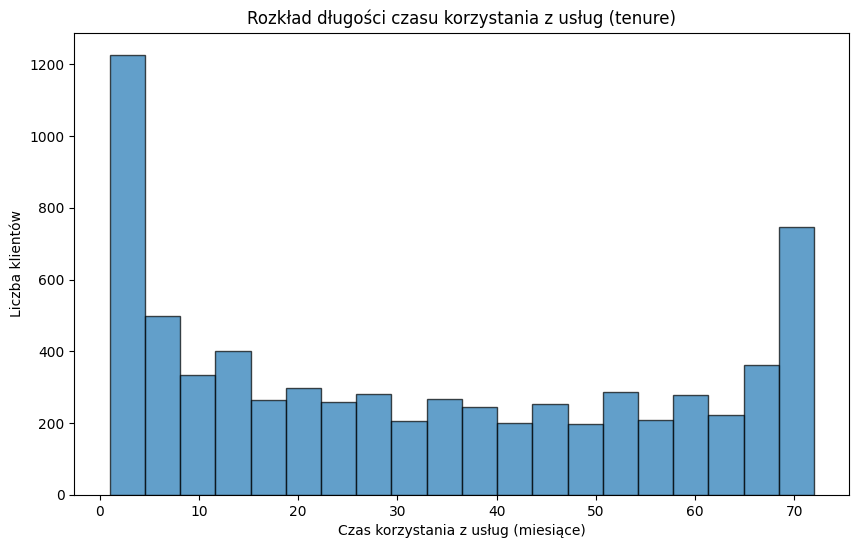

In [65]:
plt.figure(figsize=(10, 6))
plt.hist(df['tenure'], bins=20, edgecolor='black', alpha=0.7)
plt.title("Rozkład długości czasu korzystania z usług (tenure)")
plt.xlabel("Czas korzystania z usług (miesiące)")
plt.ylabel("Liczba klientów")
plt.show()

1.9. Utworzenie histogramu przedstawiającego rozkład długości czasu korzystania z usług (zmienna 'tenure'),  z  różnicowaniem  według  klientów,  którzy  odeszli  w  ciągu  ostatniego miesiąca  oraz  typu umowy. 

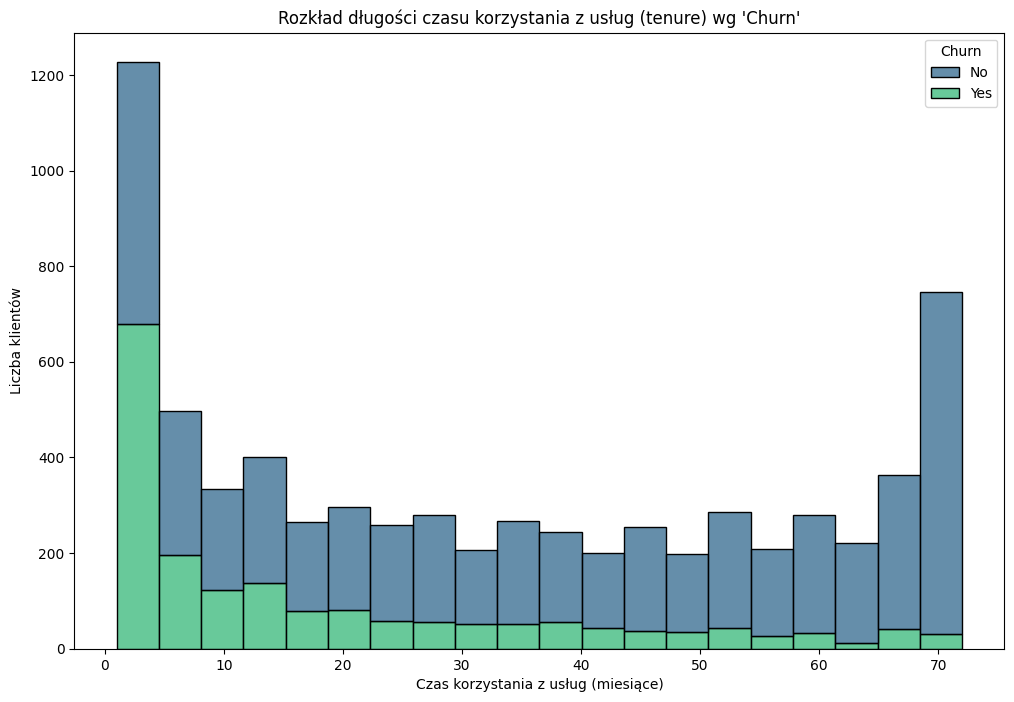

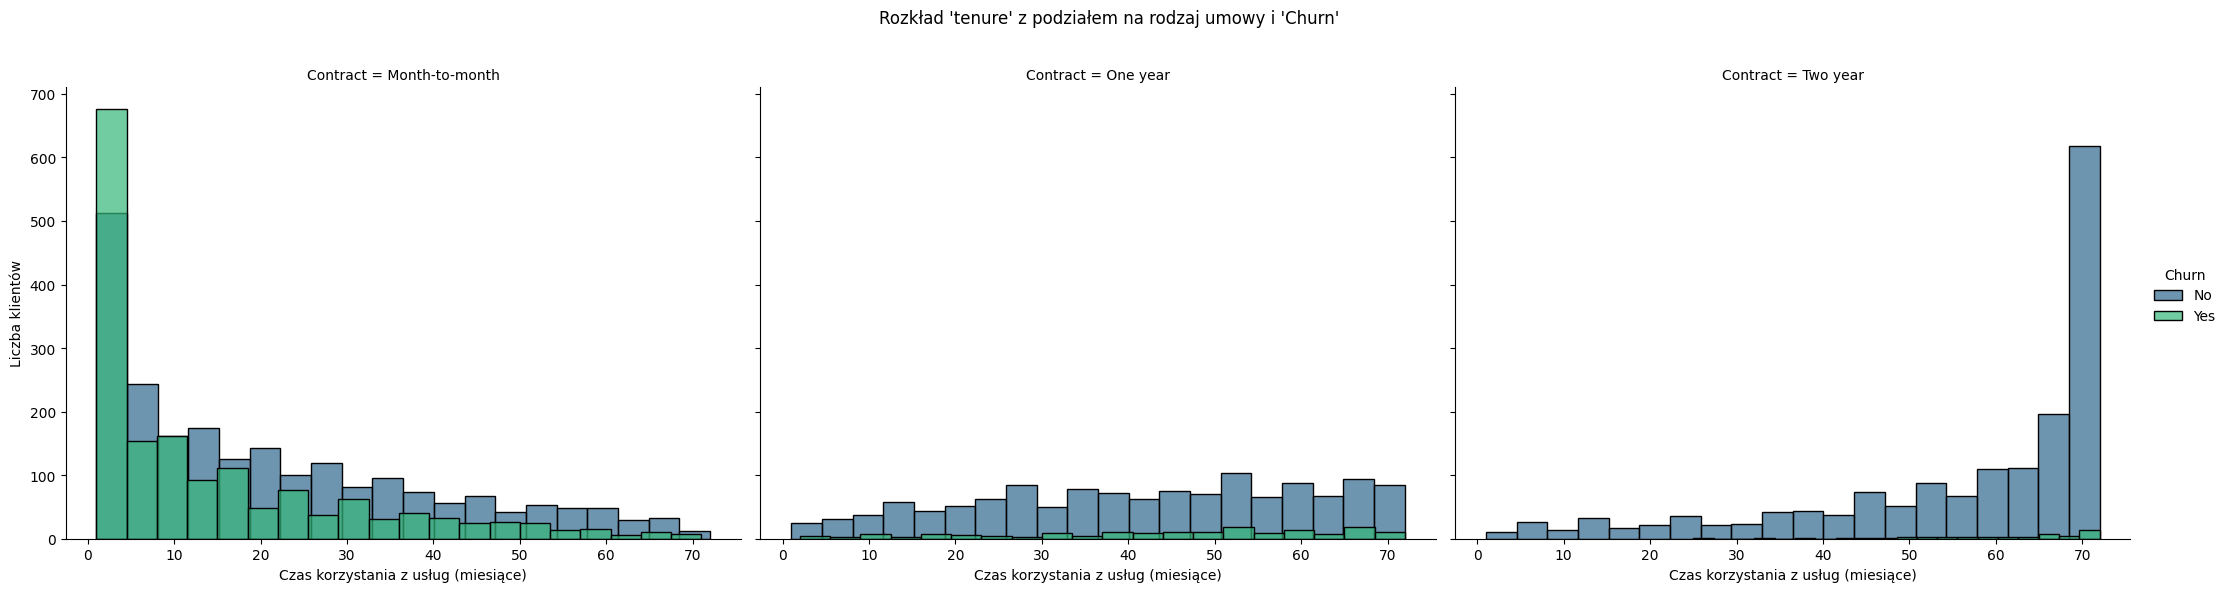

In [66]:
plt.figure(figsize=(12, 8))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', kde=False, bins=20, palette="viridis")
plt.title("Rozkład długości czasu korzystania z usług (tenure) wg 'Churn'")
plt.xlabel("Czas korzystania z usług (miesiące)")
plt.ylabel("Liczba klientów")
plt.show()

# Rozkład 'tenure' z podziałem na rodzaj umowy i 'Churn'
g = sns.FacetGrid(df, col="Contract", hue="Churn", height=6, aspect=1.2, palette="viridis")
g.map(sns.histplot, "tenure", bins=20, kde=False, alpha=0.7, edgecolor='black')
g.add_legend()
g.set_axis_labels("Czas korzystania z usług (miesiące)", "Liczba klientów")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Rozkład 'tenure' z podziałem na rodzaj umowy i 'Churn'")
plt.show()

1.10. Traktując każdą unikalną grupę 'tenure' jako kohortę (kohorta to grupa klientów, którzy mają wspólną cechę w określonym czasie. W kontekście analizy danych dotyczących churnu, kohorta może być definiowana na podstawie długości czasu korzystania z usług firmy), należy obliczyć współczynnik rezygnacji (procent osób, które zadeklarowały rezygnację) dla każdej kohorty. Na przykład w kohorcie z 1-miesięcznym stażem wskaźnik rezygnacji wynosi 61,99%. Kohorty powinny obejmować staż od 1 do 72 miesięcy, z ogólną tendencją, że im dłuższy czasu korzystania z usług, tym niższy współczynnik rezygnacji. 

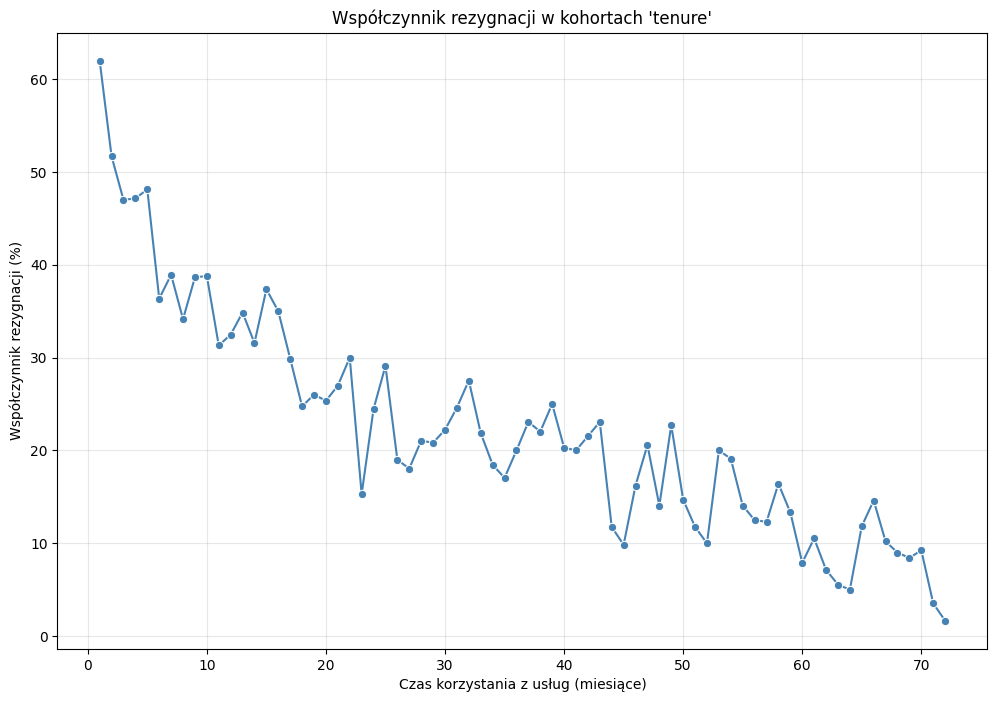

,Tenure (months),Churn Rate (%)
0,1,61.990212
1,2,51.680672
2,3,47.000000
3,4,47.159091
4,5,48.120301
5,6,36.363636
6,7,38.931298
7,8,34.146341
8,9,38.655462
9,10,38.793103


In [67]:
# Obliczanie współczynnika rezygnacji (Churn rate) dla każdej kohorty 'tenure'
churn_rate_by_tenure = df.groupby('tenure')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

# Przygotowanie danych do wizualizacji
churn_rate_by_tenure_df = churn_rate_by_tenure.reset_index()
churn_rate_by_tenure_df.columns = ['Tenure (months)', 'Churn Rate (%)']

# Wykres współczynnika rezygnacji w kohortach
plt.figure(figsize=(12, 8))
sns.lineplot(data=churn_rate_by_tenure_df, x='Tenure (months)', y='Churn Rate (%)', marker='o', color='steelblue')
plt.title("Współczynnik rezygnacji w kohortach 'tenure'")
plt.xlabel("Czas korzystania z usług (miesiące)")
plt.ylabel("Współczynnik rezygnacji (%)")
plt.grid(alpha=0.3)
plt.show()

# Wyświetlenie kilku przykładów współczynnika rezygnacji
churn_rate_by_tenure_df.head(10)

1.11. Wykres zależności współczynnika rezygnacji od 'tenure' w miesiącach.

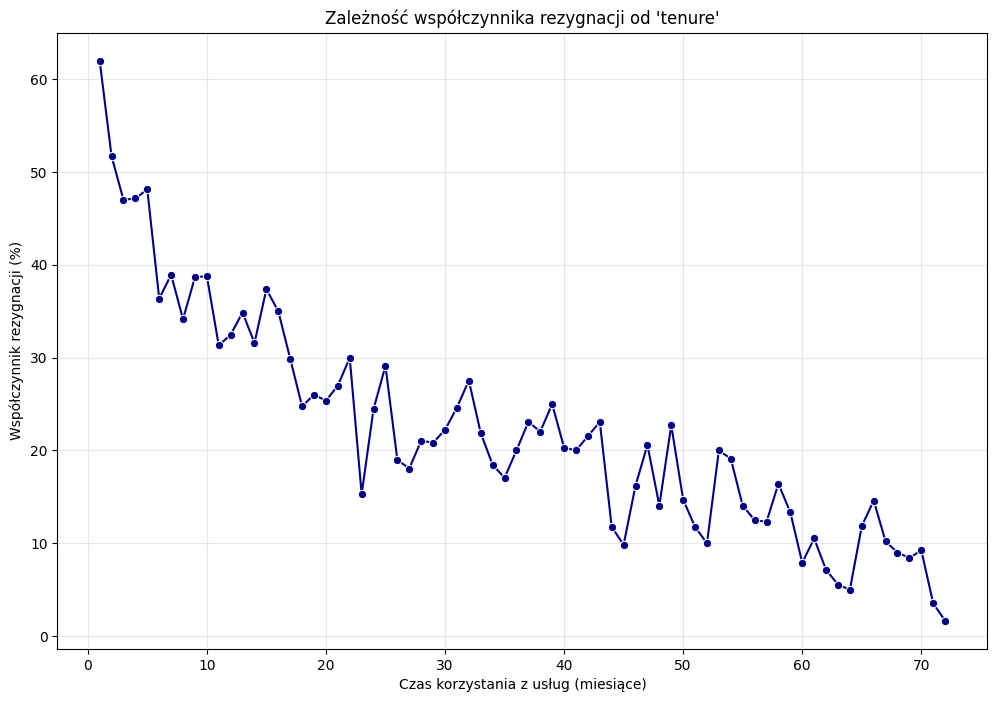

In [68]:
plt.figure(figsize=(12, 8))
sns.lineplot(data=churn_rate_by_tenure_df, x='Tenure (months)', y='Churn Rate (%)', marker='o', color='darkblue')
plt.title("Zależność współczynnika rezygnacji od 'tenure'")
plt.xlabel("Czas korzystania z usług (miesiące)")
plt.ylabel("Współczynnik rezygnacji (%)")
plt.grid(alpha=0.3)
plt.show()

1.12. Na podstawie wartości kolumny 'tenure' należy stworzyć nową kolumnę, dzieląc 'tenure' na 4 grupy: '0-12 miesięcy, '12-24 miesięcy, '24-48 miesięcy, ‘Powyżej 48 miesięcy’.

In [69]:
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12 miesięcy'
    elif tenure <= 24:
        return '12-24 miesięcy'
    elif tenure <= 48:
        return '24-48 miesięcy'
    else:
        return 'Powyżej 48 miesięcy'

df['Tenure Group'] = df['tenure'].apply(tenure_group)

1.13.  Wykres  pudełkowy  długości  czasu  korzystania  z  usług  ('tenure')  podzielony  na  4  grupy  w 
zależności od 'Churn'

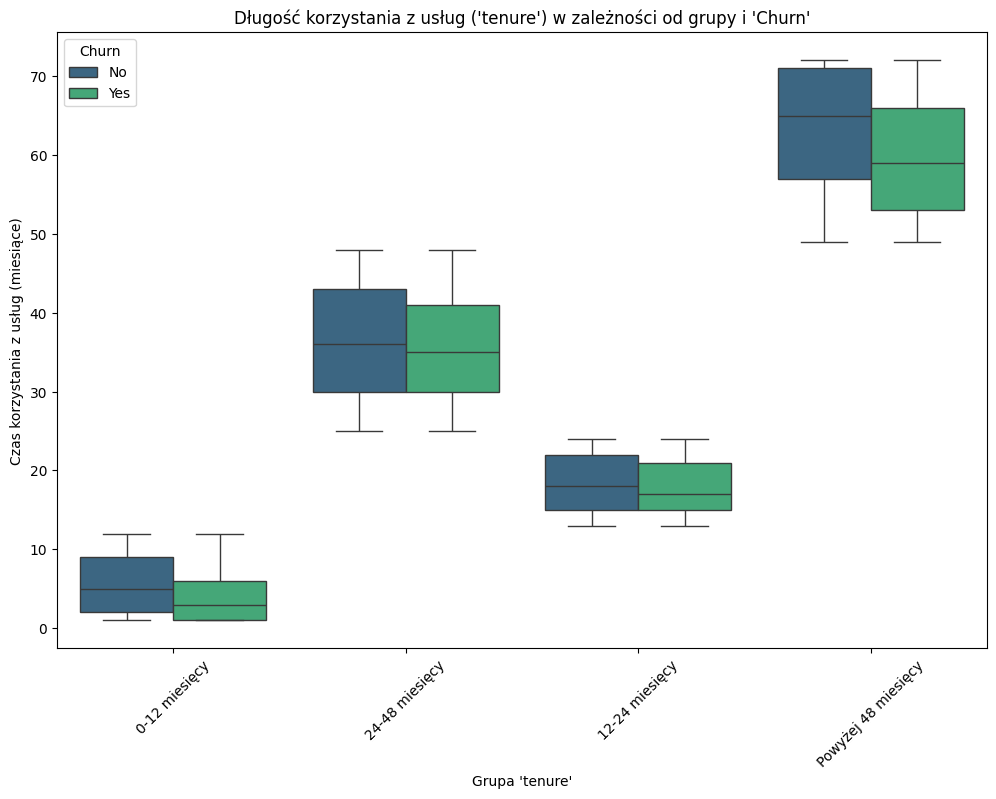

In [70]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='Tenure Group', y='tenure', hue='Churn', palette="viridis")
plt.title("Długość korzystania z usług ('tenure') w zależności od grupy i 'Churn'")
plt.xlabel("Grupa 'tenure'")
plt.ylabel("Czas korzystania z usług (miesiące)")
plt.legend(title="Churn")
plt.xticks(rotation=45)
plt.show()

### 2. Podział zbioru 
##### 2.1. Podział danych na macierz cech oraz etykiety. Należy stworzyć obiekt DataFrame z odpowiednimi zmiennymi fikcyjnymi. Należy pamiętać, że niektóre kolumny można pominąć.

In [71]:
columns_to_drop = ['customerID', 'Churn']
X = df.drop(columns=columns_to_drop)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)  # Konwersja etykiet na wartości 0 i 1

# Tworzenie zmiennych fikcyjnych dla kolumn kategorycznych
X = pd.get_dummies(X, drop_first=True)

X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure Group_12-24 miesięcy,Tenure Group_24-48 miesięcy,Tenure Group_Powyżej 48 miesięcy
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,True,False,True,False,False,True,True,False,False
7028,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,True,False,True,True,False,False,False,False,True
7029,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,True,False,True,False,False,False,False
7030,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,True,False,False,True,False,False,False


2.2. Podział zbioru danych na treningowy i testowy, z ustawionym random_state=42, tak aby zbiór testowy zawierał co najmniej 1100 przykładów.

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 33), (1407, 33), (5625,), (1407,))

## Wybór, optymalizacja modeli oraz ewaluacja 

### 3. Model drzewa decyzyjnego 
##### 3.1. Zastosowanie klasyfikatora drzewa decyzyjnego przy ustawieniach domyślnych. 
##### 3.2.  Wyświetlenie  raportu  z  klasyfikacji  oraz  macierzy  błędów  i  drzewo  decyzyjne  na  podstawie predykcji na zbiorze testowym. 
##### 3.3. Informacja nt. wagi cech. 

Raport z klasyfikacji:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80      1033
           1       0.46      0.51      0.48       374

    accuracy                           0.71      1407
   macro avg       0.64      0.65      0.64      1407
weighted avg       0.72      0.71      0.72      1407



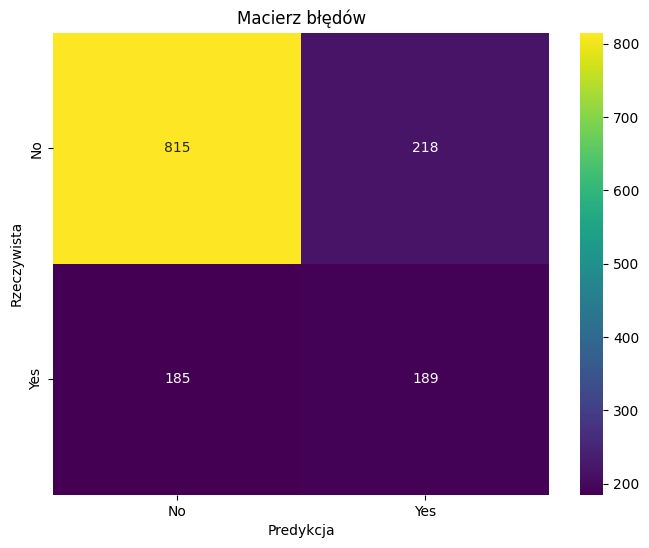

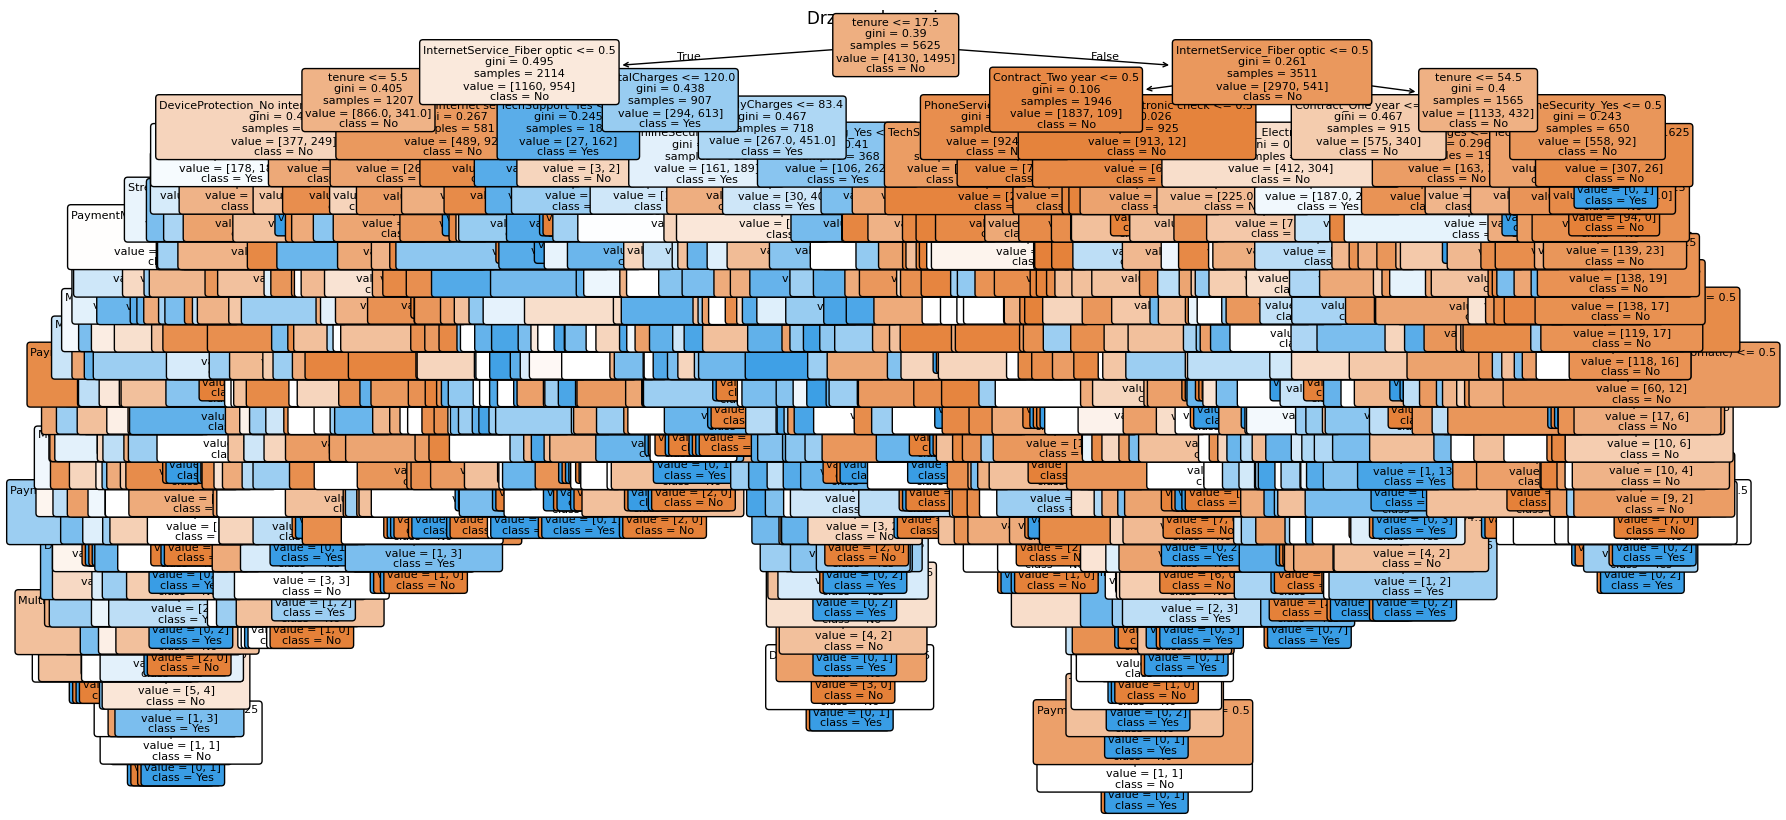

,Feature,Importance
1,tenure,0.206133
3,TotalCharges,0.188912
2,MonthlyCharges,0.187256
10,InternetService_Fiber optic,0.111978
4,gender_Male,0.031237
5,Partner_Yes,0.024641
28,PaymentMethod_Electronic check,0.020984
26,PaperlessBilling_Yes,0.020529
17,DeviceProtection_Yes,0.019391
13,OnlineSecurity_Yes,0.017414


In [73]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Zadanie 3.1: Klasyfikator drzewa decyzyjnego z ustawieniami domyślnymi
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predykcja na zbiorze testowym
y_pred = clf.predict(X_test)

# Zadanie 3.2: Raport z klasyfikacji i macierz błędów
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Wyświetlenie raportu
print("Raport z klasyfikacji:\n", classification_rep)

# Wizualizacja macierzy błędów
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Macierz błędów")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista")
plt.show()

# Wizualizacja drzewa decyzyjnego
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True, fontsize=8)
plt.title("Drzewo decyzyjne")
plt.show()

# Zadanie 3.3: Informacja nt. wagi cech
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Wyświetlenie najważniejszych cech
feature_importances.head(10)

### 4. Model k-najbliższych sąsiadów 
##### 4.1. Zastosowanie klasyfikatora k-najbliższych sąsiadów przy ustawieniach domyślnych. 
##### 4.2. Wyświetlenie  raportu  z  klasyfikacji  oraz  macierzy  błędów  na  podstawie  predykcji  na  zbiorze testowym. 

Raport z klasyfikacji (k-NN):
               precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.59      0.45      0.51       374

    accuracy                           0.77      1407
   macro avg       0.70      0.67      0.68      1407
weighted avg       0.76      0.77      0.76      1407



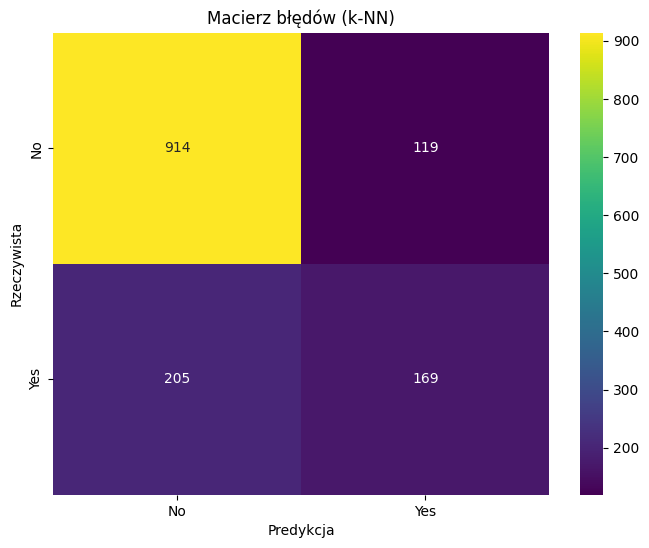

In [74]:

# Zadanie 4.1: Klasyfikator k-najbliższych sąsiadów z ustawieniami domyślnymi
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

# Predykcja na zbiorze testowym
y_pred_knn = knn.predict(X_test)

# Zadanie 4.2: Raport z klasyfikacji i macierz błędów
classification_rep_knn = classification_report(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

# Wyświetlenie raportu
print("Raport z klasyfikacji (k-NN):\n", classification_rep_knn)

# Wizualizacja macierzy błędów
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='viridis', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Macierz błędów (k-NN)")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista")
plt.show()


### 5. Model regresji logistycznej 
##### 5.1. Zastosowanie klasyfikatora regresji logistycznej przy ustawieniach domyślnych. 
##### 5.2. Wyświetlenie  raportu  z  klasyfikacji  oraz  macierzy  błędów  na  podstawie  predykcji  na  zbiorze testowym.

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Raport z klasyfikacji (Regresja Logistyczna):
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



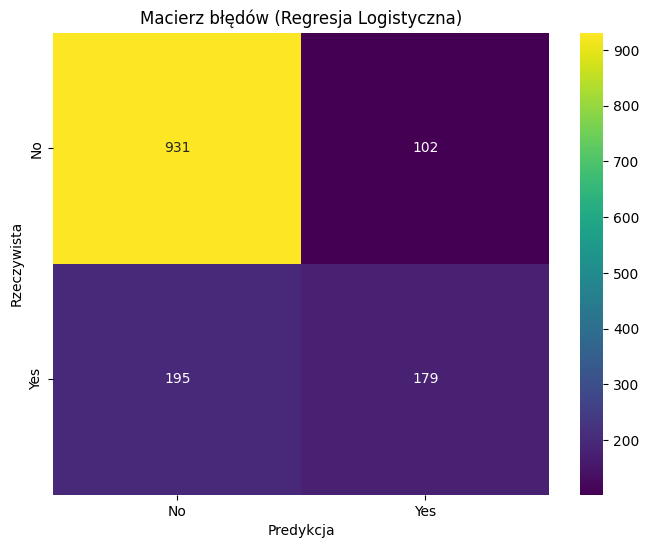

In [75]:
# Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_log_reg = log_reg.predict(X_test)

# Classification report and confusion matrix
classification_rep_log_reg = classification_report(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

# Print classification report
print("Raport z klasyfikacji (Regresja Logistyczna):\n", classification_rep_log_reg)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='viridis', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Macierz błędów (Regresja Logistyczna)")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista")
plt.show()

### 6. Porównanie klasyfikatorów 
##### 6.1. Który niezoptymalizowany klasyfikator działał najlepiej?  

In [76]:
results = {
    "Decision Tree": clf.score(X_test, y_test),
    "k-NN": knn.score(X_test, y_test),
    "Logistic Regression": log_reg.score(X_test, y_test),
}
best_model_initial = max(results, key=results.get)
best_model_initial

'Logistic Regression'

##### 6.2.  Zastosować  metodę  przeszukiwania  siatki  lub  przeszukiwania  losowego  w  celu  doboru optymalnych  parametrów  i  zbudowanie  odpowiednio  modelu  drzewa  decyzyjnego,  k-najbliższych sąsiadów i regresji logistycznej. Należy wyświetlić raporty z klasyfikacji oraz macierze błędów na podstawie predykcji na zbiorze testowym dla każdego z zoptymalizowanych klasyfikatorów. 

Decision Tree

=== Drzewo Decyzyjne (Optymalizowane) ===
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407



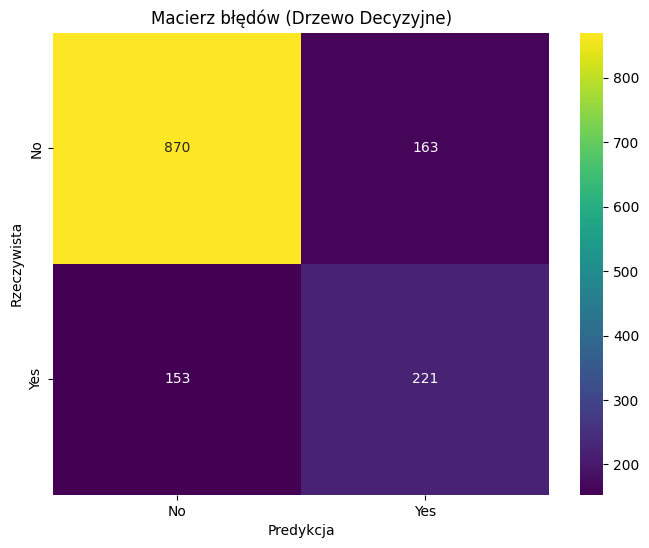

In [77]:
param_grid_dt = {'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 10, 20]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)

# Predictions for optimized Decision Tree
y_pred_dt_opt = grid_dt.best_estimator_.predict(X_test)

# Classification report and confusion matrix for Decision Tree
report_dt = classification_report(y_test, y_pred_dt_opt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt_opt)

# Display results for Decision Tree
print("=== Drzewo Decyzyjne (Optymalizowane) ===")
print(report_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='viridis', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Macierz błędów (Drzewo Decyzyjne)")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista")
plt.show()

KNN

=== k-Najbliżsi Sąsiedzi (Optymalizowane) ===
              precision    recall  f1-score   support

           0       0.82      0.92      0.86      1033
           1       0.66      0.43      0.52       374

    accuracy                           0.79      1407
   macro avg       0.74      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407



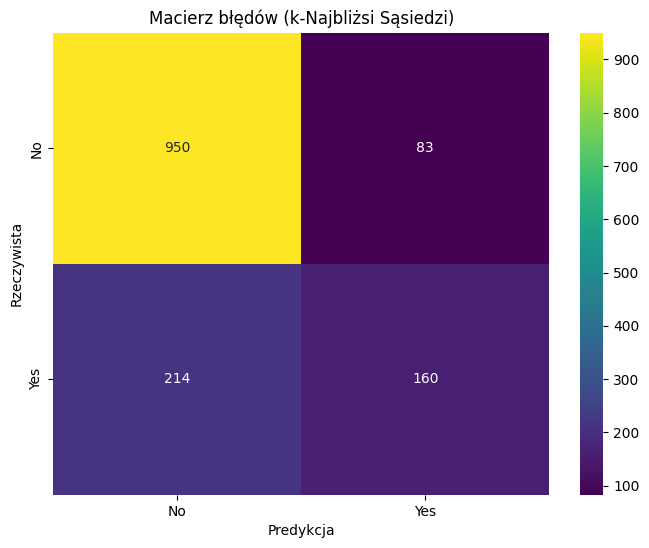

In [78]:
# RandomizedSearch for k-NN
param_dist_knn = {'n_neighbors': range(1, 21), 'weights': ['uniform', 'distance']}
random_knn = RandomizedSearchCV(KNeighborsClassifier(), param_dist_knn, n_iter=20, cv=5, random_state=42)
random_knn.fit(X_train, y_train)

# Predictions for optimized k-NN
y_pred_knn_opt = random_knn.best_estimator_.predict(X_test)

# Classification report and confusion matrix for k-NN
report_knn = classification_report(y_test, y_pred_knn_opt)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn_opt)

# Display results for k-NN
print("=== k-Najbliżsi Sąsiedzi (Optymalizowane) ===")
print(report_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='viridis', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Macierz błędów (k-Najbliżsi Sąsiedzi)")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista")
plt.show()

Logistic Regression

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

=== Regresja Logistyczna (Optymalizowana) ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



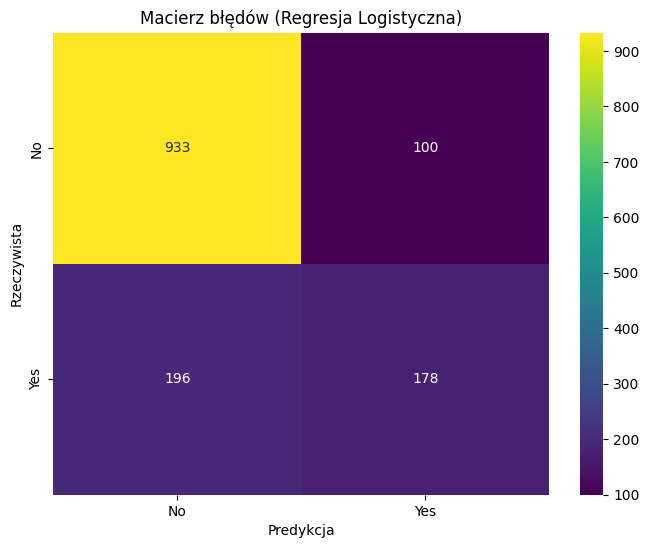

In [79]:
# GridSearch for Logistic Regression
param_grid_log = {'C': [0.01, 0.1, 1, 10, 100]}
grid_log = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_log, cv=5)
grid_log.fit(X_train, y_train)

# Predictions for optimized Logistic Regression
y_pred_log_opt = grid_log.best_estimator_.predict(X_test)

# Classification report and confusion matrix for Logistic Regression
report_log = classification_report(y_test, y_pred_log_opt)
conf_matrix_log = confusion_matrix(y_test, y_pred_log_opt)

# Display results for Logistic Regression
print("=== Regresja Logistyczna (Optymalizowana) ===")
print(report_log)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log, annot=True, fmt='d', cmap='viridis', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Macierz błędów (Regresja Logistyczna)")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista")
plt.show()

##### 6.3. Który zoptymalizowany klasyfikator działał najlepiej? Który model zoptymalizowany wykazał największą poprawę klasyfikacji względem klasyfikatora niezoptymalizowanego?

In [ ]:
# Accuracy scores for optimized models
optimized_scores = {
    "Decision Tree": grid_dt.best_estimator_.score(X_test, y_test),
    "k-NN": random_knn.best_estimator_.score(X_test, y_test),
    "Logistic Regression": grid_log.best_estimator_.score(X_test, y_test),
}

# Accuracy scores for initial (non-optimized) models
initial_scores = {
    "Decision Tree": clf.score(X_test, y_test),
    "k-NN": knn.score(X_test, y_test),
    "Logistic Regression": log_reg.score(X_test, y_test),
}

# Determine best optimized model
best_optimized_model = max(optimized_scores, key=optimized_scores.get)

# Improvement comparison
improvement = {model: optimized_scores[model] - initial_scores[model] for model in optimized_scores}
most_improved_model = max(improvement, key=improvement.get)

# Display results
print('Najlepiej zoptymalizowany model:', best_optimized_model)
print('Model, który wykazal najlepszą poprawe:', most_improved_model)
print('Accuracy for optimalized models:', optimized_scores)
print('Improvement for accuracy:', improvement) ###źle chyba ???

Najlepiej zoptymalizowany model: Logistic Regression
Model, który wykazal najlepszą poprawe: Decision Tree
Accuracy for optimalized models: {'Decision Tree': 0.775408670931059, 'k-NN': 0.7889125799573561, 'Logistic Regression': 0.7896233120113717}
Improvement for accuracy: {'Decision Tree': 0.061833688699360345, 'k-NN': 0.019189765458422214, 'Logistic Regression': 0.000710732054015617}
